In [1]:
import sys,os
sys.path.append("../../src")
from quspin.operators import hamiltonian,quantum_operator
from quspin.basis import spin_basis_1d
from quspin_functions import projector_string as Pn
from quspin_functions import TFIM 
from project_imports import *
import numpy.linalg as la
from numpy import vdot 

In [7]:
L = 10
g0 =1
tau = 20
N_timestep = 100
basis = spin_basis_1d(L,pauli=-1,pblock=-1)
H = TFIM(basis)
params = dict(H0=1,g=g0)
H0 = (H.tohamiltonian(params).todense())
E0,V0 = la.eigh(H0)
V0 = array(V0)
psi0 = V0[:,0]
P = Pn(L,"x",basis)
#psi0 = P@psi0
#psi0 = psi0/la.norm(psi0)

In [8]:
def xx_corr(l):
    # QuSpin expects site-coupling entries as [J, i, j]
    op_sites = [[1.0, 0, l]]
    ops = [["xx", op_sites]]
    opdict = dict(S=ops)

    O = quantum_operator(
        opdict,
        basis=basis,
        check_symm=False,
        check_herm=False
    )
    ss = [[1,0]]
    ops = [["x",ss]]
    opdict = dict(S=ops)
    X = quantum_operator(opdict,basis=basis,check_symm=False,check_herm=False)
    return np.asarray(O.todense()), array(X.todense())


In [9]:
dat=[]
Ls = []
for l in range(L//2+1):
    O, X= xx_corr(l)
    dat.append(vdot(psi0,O@psi0))# - vdot(psi0,X@psi0)**2)
    Ls.append(l)

Ls = array(Ls)
dat = array(dat)

/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32238/2164896869.py:5: RuntimeWarning: divide by zero encountered in matmul
  dat.append(vdot(psi0,O@psi0))# - vdot(psi0,X@psi0)**2)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32238/2164896869.py:5: RuntimeWarning: overflow encountered in matmul
  dat.append(vdot(psi0,O@psi0))# - vdot(psi0,X@psi0)**2)
/var/folders/tb/9nr_hj116ln_8s6hck886ppc0000gn/T/ipykernel_32238/2164896869.py:5: RuntimeWarning: invalid value encountered in matmul
  dat.append(vdot(psi0,O@psi0))# - vdot(psi0,X@psi0)**2)


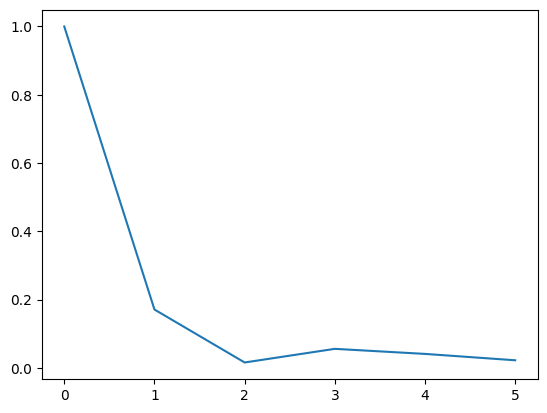

In [10]:
plot(Ls,np.abs(dat))
#yscale("log")